# Get synteny plots

This jupyter notebook was used to generate synteny plots of all *Streptomyces clavuligerus* genomes to show the conservation of gene order among genomes and genome rearrangements. 


**Step 1:** Loading modules

In [8]:
from pygenomeviz import Genbank, GenomeViz, load_dataset, Gff
from pathlib import Path
from Bio.SeqFeature import SeqFeature
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import pandas as pd
from pygenomeviz.align import MUMmer, AlignCoord, MMseqs
from tempfile import TemporaryDirectory
from pathlib import Path
from pygenomeviz import Gff, GenomeViz, load_example_gff
from Bio import SeqIO
from Bio.Seq import Seq

**Step 2:** Generate synteny plots. 

The plots will be generated with the Python package pyGenomeViz. For more information visit [here](https://moshi4.github.io/pyGenomeViz/). 

In [9]:
datadir = Path("../output/new_files/")
filenames = sorted(datadir.glob("*/*.gbk"))

In [10]:
#Create graph
gv = GenomeViz(
    fig_track_height=0.7,
    link_track_ratio=2.0,
    align_type="center",
    tick_style="bar",
)



gbk_list = [Genbank(f) for f in filenames if '.DS' not in str(f)]

    

# gbk_list = [Genbank(f) for f in filenames]
for gbk in gbk_list:
    print(gbk.range_size)
    track = gv.add_feature_track(gbk.name, size=gbk.range_size, start_pos=gbk.min_range, labelsize= 10)
    track.add_genbank_features(gbk,   facecolor="black")

    

# Run MUMmer alignment
with TemporaryDirectory() as tmpdir:
    # seqtype='nucleotide'|'protein', maptype='one-to-one'|'many-to-many'
    align_coords = MUMmer(gbk_list, tmpdir, seqtype="nucleotide", maptype="many-to-many").run()
    # Filter alignment results by 'min_length', 'min_identity' threshold
    align_coords = AlignCoord.filter(align_coords, min_length=0, min_identity=0)
    # Write alignment result as tsv format file
    AlignCoord.write(align_coords, f"{tmpdir}/align_coords.tsv")

min_identity = int(min([ac.identity for ac in align_coords]))


for ac in align_coords:
    link1 = (ac.ref_name, ac.ref_start, ac.ref_end)
    link2 = (ac.query_name, ac.query_start, ac.query_end)
    gv.add_link(link1, link2, curve=True, v=ac.identity, vmin=min_identity)

fig = gv.plotfig()

gv.set_colorbar(fig, vmin=min_identity)


# Add Legends (Maybe there is a better way)
handles = [
    Line2D([], [], marker=">", color="black", label="CDS", ms=10, ls="none"),
    Patch(color="grey", label="Normal Link"),
    Patch(color="red", label="Inverted Link"),
    Patch(color="orange", label="Chromosome", alpha=0.5),
    Patch(color="lime", label="pSCL1", alpha=0.5),
    Patch(color="firebrick", label="pSCL2",alpha=0.5),
    Patch(color="slateblue", label="pSCL3",alpha=0.5),
    Patch(color="salmon", label="pSCL4", alpha=0.5),
    
]
legend = fig.legend(handles=handles, bbox_to_anchor=(1, 1))




target_track = gv.get_track("SC6-2_16-11-23")
box_xmin, box_xmax = 1, 6553311
box_xmin += target_track.offset  # Offset is required if align_type is not 'left'
box_xmax += target_track.offset
x, y = (box_xmin, box_xmin, box_xmax, box_xmax), (1, -1, -1, 1)
target_track.ax.fill(x, y, fc="orange", linewidth=0, alpha=0.5, zorder=-10)


target_track = gv.get_track("SC6-2_16-11-23")
box_xmin, box_xmax = 6553312, 6565033
box_xmin += target_track.offset  # Offset is required if align_type is not 'left'
box_xmax += target_track.offset
x, y = (box_xmin, box_xmin, box_xmax, box_xmax), (1, -1, -1, 1)
target_track.ax.fill(x, y, fc="lime", linewidth=0, alpha=0.5, zorder=-10)

target_track = gv.get_track("SC6-2_16-11-23")
box_xmin, box_xmax = 6565034, 6714479
box_xmin += target_track.offset  # Offset is required if align_type is not 'left'
box_xmax += target_track.offset
x, y = (box_xmin, box_xmin, box_xmax, box_xmax), (1, -1, -1, 1)
target_track.ax.fill(x, y, fc="firebrick", linewidth=0, alpha=0.5, zorder=-10)


target_track = gv.get_track("SC6-2_16-11-23")
box_xmin, box_xmax = 6714480, 7159373
box_xmin += target_track.offset  # Offset is required if align_type is not 'left'
box_xmax += target_track.offset
x, y = (box_xmin, box_xmin, box_xmax, box_xmax), (1, -1, -1, 1)
target_track.ax.fill(x, y, fc="slateblue", linewidth=0, alpha=0.5, zorder=-10)

target_track = gv.get_track("SC6-2_16-11-23")
box_xmin, box_xmax = 7159374, 8122614
box_xmin += target_track.offset  # Offset is required if align_type is not 'left'
box_xmax += target_track.offset
x, y = (box_xmin, box_xmin, box_xmax, box_xmax), (1, -1, -1, 1)
target_track.ax.fill(x, y, fc="salmon", linewidth=0, alpha=0.5, zorder=-10)












target_track = gv.get_track("SC6-1_16-11-23")
box_xmin, box_xmax = 1, 6553311
box_xmin += target_track.offset  # Offset is required if align_type is not 'left'
box_xmax += target_track.offset
x, y = (box_xmin, box_xmin, box_xmax, box_xmax), (1, -1, -1, 1)
target_track.ax.fill(x, y, fc="orange", linewidth=0, alpha=0.5, zorder=-10)


target_track = gv.get_track("SC6-1_16-11-23")
box_xmin, box_xmax = 6553312, 6702757
box_xmin += target_track.offset  # Offset is required if align_type is not 'left'
box_xmax += target_track.offset
x, y = (box_xmin, box_xmin, box_xmax, box_xmax), (1, -1, -1, 1)
target_track.ax.fill(x, y, fc="firebrick", linewidth=0, alpha=0.5, zorder=-10)


target_track = gv.get_track("SC6-1_16-11-23")
box_xmin, box_xmax = 6702758, 7147651
box_xmin += target_track.offset  # Offset is required if align_type is not 'left'
box_xmax += target_track.offset
x, y = (box_xmin, box_xmin, box_xmax, box_xmax), (1, -1, -1, 1)
target_track.ax.fill(x, y, fc="slateblue", linewidth=0, alpha=0.5, zorder=-10)


target_track = gv.get_track("SC6-1_16-11-23")
box_xmin, box_xmax = 7147652, 8116227
box_xmin += target_track.offset  # Offset is required if align_type is not 'left'
box_xmax += target_track.offset
x, y = (box_xmin, box_xmin, box_xmax, box_xmax), (1, -1, -1, 1)
target_track.ax.fill(x, y, fc="salmon", linewidth=0, alpha=0.5, zorder=-10)









target_track = gv.get_track("SC5_27_01-22")
box_xmin, box_xmax = 1, 6748866
box_xmin += target_track.offset  # Offset is required if align_type is not 'left'
box_xmax += target_track.offset
x, y = (box_xmin, box_xmin, box_xmax, box_xmax), (1, -1, -1, 1)
target_track.ax.fill(x, y, fc="orange", linewidth=0, alpha=0.5, zorder=-10)


target_track = gv.get_track("SC5_27_01-22")
box_xmin, box_xmax = 6748867, 6760588
box_xmin += target_track.offset  # Offset is required if align_type is not 'left'
box_xmax += target_track.offset
x, y = (box_xmin, box_xmin, box_xmax, box_xmax), (1, -1, -1, 1)
target_track.ax.fill(x, y, fc="lime", linewidth=0, alpha=0.5, zorder=-10)

target_track = gv.get_track("SC5_27_01-22")
box_xmin, box_xmax = 6760589, 6909465
box_xmin += target_track.offset  # Offset is required if align_type is not 'left'
box_xmax += target_track.offset
x, y = (box_xmin, box_xmin, box_xmax, box_xmax), (1, -1, -1, 1)
target_track.ax.fill(x, y, fc="firebrick", linewidth=0, alpha=0.5, zorder=-10)


target_track = gv.get_track("SC5_27_01-22")
box_xmin, box_xmax = 6909466, 7358312
box_xmin += target_track.offset  # Offset is required if align_type is not 'left'
box_xmax += target_track.offset
x, y = (box_xmin, box_xmin, box_xmax, box_xmax), (1, -1, -1, 1)
target_track.ax.fill(x, y, fc="slateblue", linewidth=0, alpha=0.5, zorder=-10)

target_track = gv.get_track("SC5_27_01-22")
box_xmin, box_xmax = 7358313, 8194284
box_xmin += target_track.offset  # Offset is required if align_type is not 'left'
box_xmax += target_track.offset
x, y = (box_xmin, box_xmin, box_xmax, box_xmax), (1, -1, -1, 1)
target_track.ax.fill(x, y, fc="salmon", linewidth=0, alpha=0.5, zorder=-10)




target_track = gv.get_track("SC4_27-01-22")
box_xmin, box_xmax = 1, 6748913
box_xmin += target_track.offset  # Offset is required if align_type is not 'left'
box_xmax += target_track.offset
x, y = (box_xmin, box_xmin, box_xmax, box_xmax), (1, -1, -1, 1)
target_track.ax.fill(x, y, fc="orange", linewidth=0, alpha=0.5, zorder=-10)

target_track = gv.get_track("SC4_27-01-22")
box_xmin, box_xmax = 6748914, 6760635
box_xmin += target_track.offset  # Offset is required if align_type is not 'left'
box_xmax += target_track.offset
x, y = (box_xmin, box_xmin, box_xmax, box_xmax), (1, -1, -1, 1)
target_track.ax.fill(x, y, fc="lime", linewidth=0, alpha=0.5, zorder=-10)

target_track = gv.get_track("SC4_27-01-22")
box_xmin, box_xmax = 6760636, 6909512
box_xmin += target_track.offset  # Offset is required if align_type is not 'left'
box_xmax += target_track.offset
x, y = (box_xmin, box_xmin, box_xmax, box_xmax), (1, -1, -1, 1)
target_track.ax.fill(x, y, fc="firebrick", linewidth=0, alpha=0.5, zorder=-10)


target_track = gv.get_track("SC4_27-01-22")
box_xmin, box_xmax = 6909513, 7358359
box_xmin += target_track.offset  # Offset is required if align_type is not 'left'
box_xmax += target_track.offset
x, y = (box_xmin, box_xmin, box_xmax, box_xmax), (1, -1, -1, 1)
target_track.ax.fill(x, y, fc="slateblue", linewidth=0, alpha=0.5, zorder=-10)

target_track = gv.get_track("SC4_27-01-22")
box_xmin, box_xmax = 7358360, 8194331
box_xmin += target_track.offset  # Offset is required if align_type is not 'left'
box_xmax += target_track.offset
x, y = (box_xmin, box_xmin, box_xmax, box_xmax), (1, -1, -1, 1)
target_track.ax.fill(x, y, fc="salmon", linewidth=0, alpha=0.5, zorder=-10)








target_track = gv.get_track("SC3_16-11-23")
box_xmin, box_xmax = 1, 6748915
box_xmin += target_track.offset  # Offset is required if align_type is not 'left'
box_xmax += target_track.offset
x, y = (box_xmin, box_xmin, box_xmax, box_xmax), (1, -1, -1, 1)
target_track.ax.fill(x, y, fc="orange", linewidth=0, alpha=0.5, zorder=-10)

target_track = gv.get_track("SC3_16-11-23")
box_xmin, box_xmax = 6748916, 6760637
box_xmin += target_track.offset  # Offset is required if align_type is not 'left'
box_xmax += target_track.offset
x, y = (box_xmin, box_xmin, box_xmax, box_xmax), (1, -1, -1, 1)
target_track.ax.fill(x, y, fc="lime", linewidth=0, alpha=0.5, zorder=-10)

target_track = gv.get_track("SC3_16-11-23")
box_xmin, box_xmax = 6760638,6909514
box_xmin += target_track.offset  # Offset is required if align_type is not 'left'
box_xmax += target_track.offset
x, y = (box_xmin, box_xmin, box_xmax, box_xmax), (1, -1, -1, 1)
target_track.ax.fill(x, y, fc="firebrick", linewidth=0, alpha=0.5, zorder=-10)

target_track = gv.get_track("SC3_16-11-23")
box_xmin, box_xmax = 6909515, 7358361
box_xmin += target_track.offset  # Offset is required if align_type is not 'left'
box_xmax += target_track.offset
x, y = (box_xmin, box_xmin, box_xmax, box_xmax), (1, -1, -1, 1)
target_track.ax.fill(x, y, fc="slateblue", linewidth=0, alpha=0.5, zorder=-10)



target_track = gv.get_track("SC3_16-11-23")
box_xmin, box_xmax = 7358362, 8194333
box_xmin += target_track.offset  # Offset is required if align_type is not 'left'
box_xmax += target_track.offset
x, y = (box_xmin, box_xmin, box_xmax, box_xmax), (1, -1, -1, 1)
target_track.ax.fill(x, y, fc="salmon", linewidth=0, alpha=0.5, zorder=-10)






target_track = gv.get_track("SC2-1_19-01-22")
box_xmin, box_xmax = 1, 6748915
box_xmin += target_track.offset  # Offset is required if align_type is not 'left'
box_xmax += target_track.offset
x, y = (box_xmin, box_xmin, box_xmax, box_xmax), (1, -1, -1, 1)
target_track.ax.fill(x, y, fc="orange", linewidth=0, alpha=0.5, zorder=-10)

target_track = gv.get_track("SC2-1_19-01-22")
box_xmin, box_xmax = 6748916, 6760637
box_xmin += target_track.offset  # Offset is required if align_type is not 'left'
box_xmax += target_track.offset
x, y = (box_xmin, box_xmin, box_xmax, box_xmax), (1, -1, -1, 1)
target_track.ax.fill(x, y, fc="lime", linewidth=0, alpha=0.5, zorder=-10)

target_track = gv.get_track("SC2-1_19-01-22")
box_xmin, box_xmax = 6760638,6909514
box_xmin += target_track.offset  # Offset is required if align_type is not 'left'
box_xmax += target_track.offset
x, y = (box_xmin, box_xmin, box_xmax, box_xmax), (1, -1, -1, 1)
target_track.ax.fill(x, y, fc="firebrick", linewidth=0, alpha=0.5, zorder=-10)

target_track = gv.get_track("SC2-1_19-01-22")
box_xmin, box_xmax = 6909515, 7358361
box_xmin += target_track.offset  # Offset is required if align_type is not 'left'
box_xmax += target_track.offset
x, y = (box_xmin, box_xmin, box_xmax, box_xmax), (1, -1, -1, 1)
target_track.ax.fill(x, y, fc="slateblue", linewidth=0, alpha=0.5, zorder=-10)


target_track = gv.get_track("SC2-1_19-01-22")
box_xmin, box_xmax = 7358362, 8194333
box_xmin += target_track.offset  # Offset is required if align_type is not 'left'
box_xmax += target_track.offset
x, y = (box_xmin, box_xmin, box_xmax, box_xmax), (1, -1, -1, 1)
target_track.ax.fill(x, y, fc="salmon", linewidth=0, alpha=0.5, zorder=-10)






target_track = gv.get_track("SC2-2_16-11-23")
box_xmin, box_xmax = 1, 6595486
box_xmin += target_track.offset  # Offset is required if align_type is not 'left'
box_xmax += target_track.offset
x, y = (box_xmin, box_xmin, box_xmax, box_xmax), (1, -1, -1, 1)
target_track.ax.fill(x, y, fc="orange", linewidth=0, alpha=0.5, zorder=-10)


target_track = gv.get_track("SC2-2_16-11-23")
box_xmin, box_xmax = 6595487, 6607208
box_xmin += target_track.offset  # Offset is required if align_type is not 'left'
box_xmax += target_track.offset
x, y = (box_xmin, box_xmin, box_xmax, box_xmax), (1, -1, -1, 1)
target_track.ax.fill(x, y, fc="lime", linewidth=0, alpha=0.5, zorder=-10)

target_track = gv.get_track("SC2-2_16-11-23")
box_xmin, box_xmax = 6607209,6756085
box_xmin += target_track.offset  # Offset is required if align_type is not 'left'
box_xmax += target_track.offset
x, y = (box_xmin, box_xmin, box_xmax, box_xmax), (1, -1, -1, 1)
target_track.ax.fill(x, y, fc="firebrick", linewidth=0, alpha=0.5, zorder=-10)

target_track = gv.get_track("SC2-2_16-11-23")
box_xmin, box_xmax = 6756085, 7592057
box_xmin += target_track.offset  # Offset is required if align_type is not 'left'
box_xmax += target_track.offset
x, y = (box_xmin, box_xmin, box_xmax, box_xmax), (1, -1, -1, 1)
target_track.ax.fill(x, y, fc="salmon", linewidth=0, alpha=0.5, zorder=-10)


#Save Figure as.
fig.savefig(f"../output/plots/original_synteny_plots.pdf")







7592057
8194129
8194333
8194331
8194284


ValueError: track.name='PROKKA_07012024' is already exists.

For an easier interpretation of the synteny plot it was decided that a reversed complement of pSCL3 for SC2-1 and SC3, as well as reversed complements of pSCL2 and pSCL4 for SC6-1 should be used. 

**Step 3:** Generation of the appropriate input

In [4]:
datadir = Path("fna")
filenames = sorted(datadir.glob("*"))

In [35]:
def reverse_plasmids(gbk_file, plasmids_to_reverse, output_file):
    
    records = list(SeqIO.parse(gbk_file, 'genbank'))
    
    for record in records:
        if record.name in plasmids_to_reverse:
            record.seq = record.seq.reverse_complement()
        else:
            record.seq = record.seq 
    
    SeqIO.write(records, output_file, 'genbank')
        
        
        
    
    
    
reverse_plasmids('../output/prokka/SC2-1_19-01-22/SC2-1_19-01-22.gbk', ["MIAHBOEK_4"], '../output/rearranged_gbk/SC2-1_19-01-22.gbk')    
reverse_plasmids('../output/prokka/SC3_16-11-23/SC3_16-11-23.gbk', ["DIHKAOLC_4"], '../output/rearranged_gbk/SC3_16-11-23.gbk')    
reverse_plasmids('../output/prokka/SC6-1_16-11-23/SC6-1_16-11-23.gbk', ["NDAGFAHJ_2", "NDAGFAHJ_4", "NDAGFAHJ_3"], '../output/rearranged_gbk/SC6-1_16-11-23.gbk')    
reverse_plasmids('../output/prokka/SC6-2_16-11-23/SC6-2_16-11-23.gbk', ["OEINHMMP_3", "OEINHMMP_5", "OEINHMMP_4"], '../output/rearranged_gbk/SC6-2_16-11-23.gbk')    
reverse_plasmids('../output/prokka/SC4_27-01-22/SC4_27-01-22.gbk', ["OPCBJEGO_4"], '../output/rearranged_gbk/SC4_27-01-22.gbk')    
reverse_plasmids('../output/prokka/SC5_27_01-22/SC5_27_01-22.gbk', ["NAIBEHKO_4"], '../output/rearranged_gbk/SC5_27_01-22.gbk')    





In [2]:
datadir = Path("../output/rearranged_gbk/")
filenames = sorted(datadir.glob("*.gbk"))

8194333
7592057
8194333
8194331
8194284
8116227
8122614


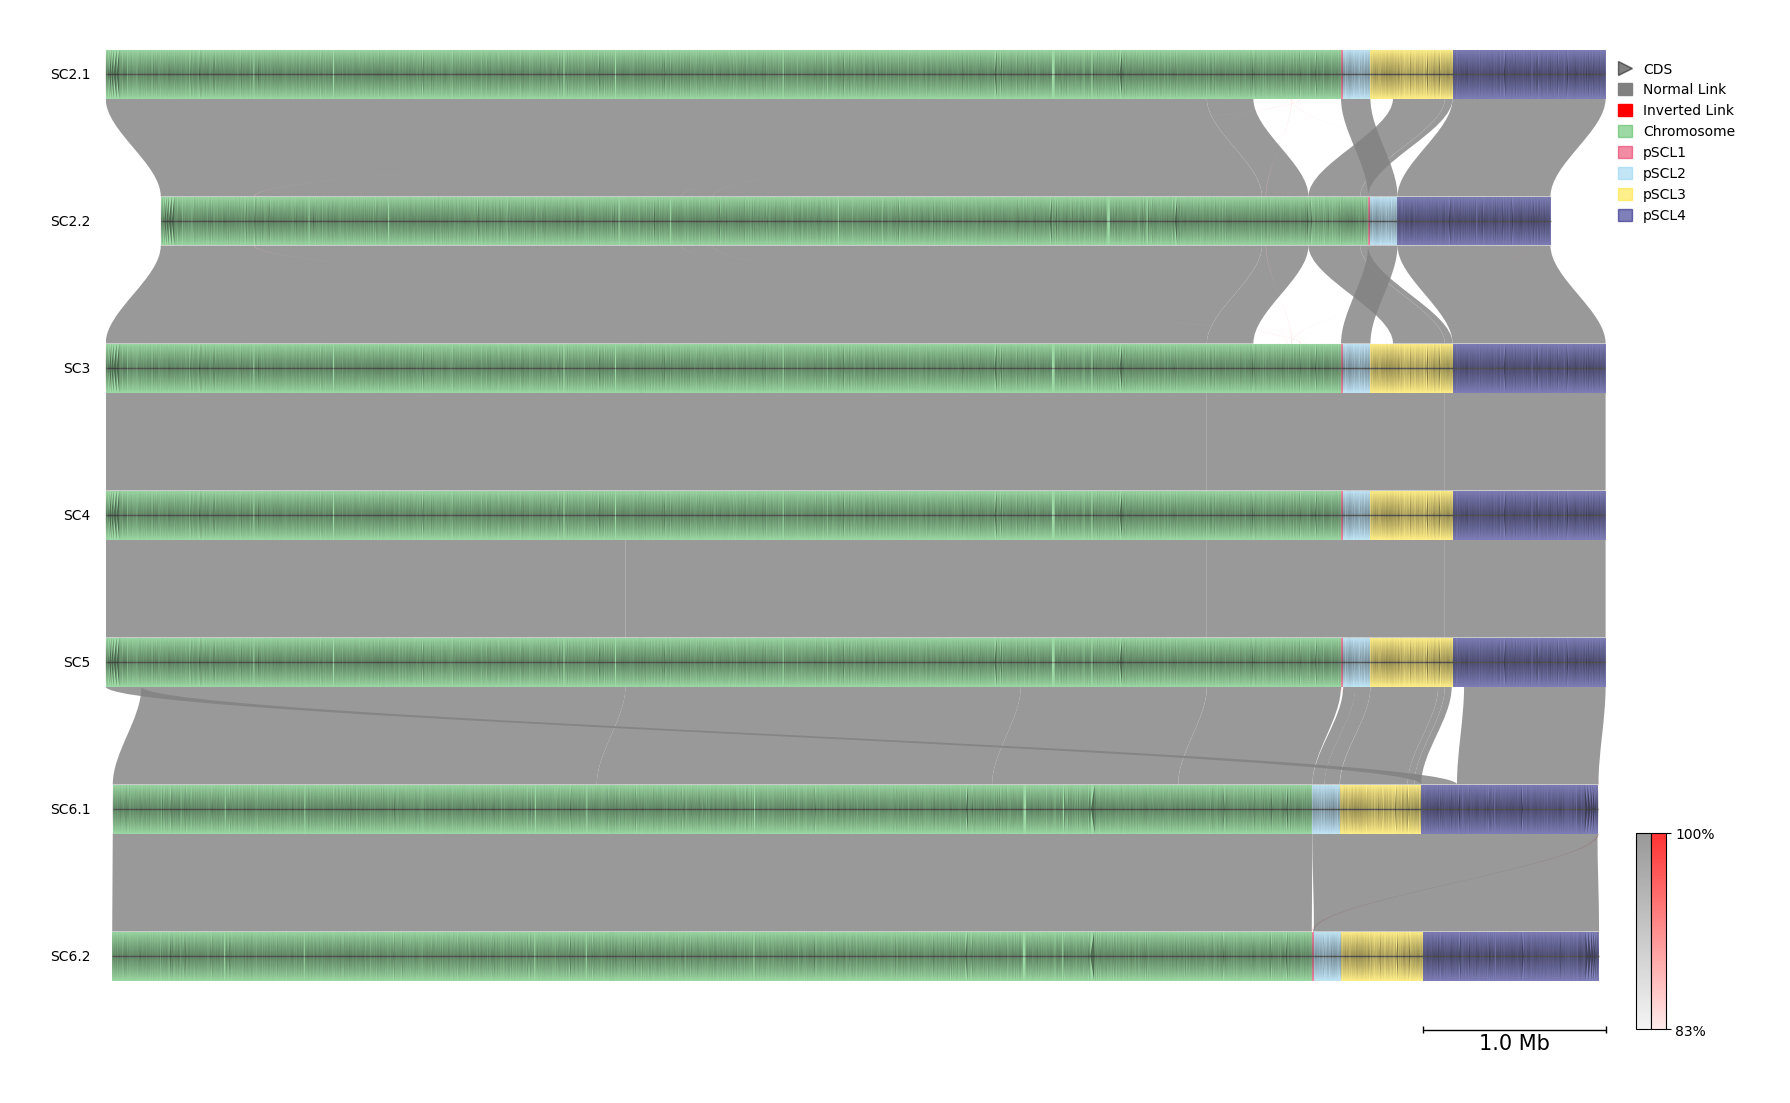

In [12]:
#Create graph
gv = GenomeViz(
    fig_track_height=0.7,
    link_track_ratio=2.0,
    align_type="center",
    tick_style="bar",
    feature_track_ratio=1.0
)



gbk_list = [Genbank(f) for f in filenames if '.DS' not in str(f)]

    

# gbk_list = [Genbank(f) for f in filenames]
for gbk in gbk_list:
    print(gbk.range_size)
    track = gv.add_feature_track(gbk.name, size=gbk.range_size, start_pos=gbk.min_range, labelsize= 10)
    track.add_genbank_features(gbk,   facecolor="#00000080")

    

# Run MUMmer alignment
with TemporaryDirectory() as tmpdir:
    # seqtype='nucleotide'|'protein', maptype='one-to-one'|'many-to-many'
    align_coords = MUMmer(gbk_list, tmpdir, seqtype="nucleotide", maptype="many-to-many").run()
    # Filter alignment results by 'min_length', 'min_identity' threshold
    align_coords = AlignCoord.filter(align_coords, min_length=0, min_identity=0)
    # Write alignment result as tsv format file
    AlignCoord.write(align_coords, f"{tmpdir}/align_coords.tsv")

min_identity = int(min([ac.identity for ac in align_coords]))


for ac in align_coords:
    link1 = (ac.ref_name, ac.ref_start, ac.ref_end)
    link2 = (ac.query_name, ac.query_start, ac.query_end)
    gv.add_link(link1, link2, curve=True, v=ac.identity, vmin=min_identity)

fig = gv.plotfig()

gv.set_colorbar(fig, vmin=min_identity)


# Add Legends (Maybe there is a better way)
handles = [
    Line2D([], [], marker=">", color="#00000080", label="CDS", ms=10, ls="none"),
    Patch(color="grey", label="Normal Link"),
    Patch(color="red", label="Inverted Link"),
    Patch(color="#3cb44b", label="Chromosome", alpha=0.5),
    Patch(color="#e6194B", label="pSCL1", alpha=0.5),
    Patch(color="#89CFF0", label="pSCL2",alpha=0.5),
    Patch(color="#ffe119", label="pSCL3",alpha=0.5),
    Patch(color="#000075", label="pSCL4", alpha=0.5),
    
]
legend = fig.legend(handles=handles, bbox_to_anchor=(1, 1))




target_track = gv.get_track("SC6.2")
box_xmin, box_xmax = 1, 6553311
box_xmin += target_track.offset  # Offset is required if align_type is not 'left'
box_xmax += target_track.offset
x, y = (box_xmin, box_xmin, box_xmax, box_xmax), (1, -1, -1, 1)
target_track.ax.fill(x, y, fc="#3cb44b", linewidth=0, alpha=0.5, zorder=-10)


target_track = gv.get_track("SC6.2")
box_xmin, box_xmax = 6553312, 6565033
box_xmin += target_track.offset  # Offset is required if align_type is not 'left'
box_xmax += target_track.offset
x, y = (box_xmin, box_xmin, box_xmax, box_xmax), (1, -1, -1, 1)
target_track.ax.fill(x, y, fc="#e6194B", linewidth=0, alpha=0.5, zorder=-10)

target_track = gv.get_track("SC6.2")
box_xmin, box_xmax = 6565034, 6714479
box_xmin += target_track.offset  # Offset is required if align_type is not 'left'
box_xmax += target_track.offset
x, y = (box_xmin, box_xmin, box_xmax, box_xmax), (1, -1, -1, 1)
target_track.ax.fill(x, y, fc="#89CFF0", linewidth=0, alpha=0.5, zorder=-10)


target_track = gv.get_track("SC6.2")
box_xmin, box_xmax = 6714480, 7159373
box_xmin += target_track.offset  # Offset is required if align_type is not 'left'
box_xmax += target_track.offset
x, y = (box_xmin, box_xmin, box_xmax, box_xmax), (1, -1, -1, 1)
target_track.ax.fill(x, y, fc="#ffe119", linewidth=0, alpha=0.5, zorder=-10)

target_track = gv.get_track("SC6.2")
box_xmin, box_xmax = 7159374, 8122614
box_xmin += target_track.offset  # Offset is required if align_type is not 'left'
box_xmax += target_track.offset
x, y = (box_xmin, box_xmin, box_xmax, box_xmax), (1, -1, -1, 1)
target_track.ax.fill(x, y, fc="#000075", linewidth=0, alpha=0.5, zorder=-10)












target_track = gv.get_track("SC6.1")
box_xmin, box_xmax = 1, 6553311
box_xmin += target_track.offset  # Offset is required if align_type is not 'left'
box_xmax += target_track.offset
x, y = (box_xmin, box_xmin, box_xmax, box_xmax), (1, -1, -1, 1)
target_track.ax.fill(x, y, fc="#3cb44b", linewidth=0, alpha=0.5, zorder=-10)


target_track = gv.get_track("SC6.1")
box_xmin, box_xmax = 6553312, 6702757
box_xmin += target_track.offset  # Offset is required if align_type is not 'left'
box_xmax += target_track.offset
x, y = (box_xmin, box_xmin, box_xmax, box_xmax), (1, -1, -1, 1)
target_track.ax.fill(x, y, fc="#89CFF0", linewidth=0, alpha=0.5, zorder=-10)


target_track = gv.get_track("SC6.1")
box_xmin, box_xmax = 6702758, 7147651
box_xmin += target_track.offset  # Offset is required if align_type is not 'left'
box_xmax += target_track.offset
x, y = (box_xmin, box_xmin, box_xmax, box_xmax), (1, -1, -1, 1)
target_track.ax.fill(x, y, fc="#ffe119", linewidth=0, alpha=0.5, zorder=-10)


target_track = gv.get_track("SC6.1")
box_xmin, box_xmax = 7147652, 8116227
box_xmin += target_track.offset  # Offset is required if align_type is not 'left'
box_xmax += target_track.offset
x, y = (box_xmin, box_xmin, box_xmax, box_xmax), (1, -1, -1, 1)
target_track.ax.fill(x, y, fc="#000075", linewidth=0, alpha=0.5, zorder=-10)









target_track = gv.get_track("SC5")
box_xmin, box_xmax = 1, 6748866
box_xmin += target_track.offset  # Offset is required if align_type is not 'left'
box_xmax += target_track.offset
x, y = (box_xmin, box_xmin, box_xmax, box_xmax), (1, -1, -1, 1)
target_track.ax.fill(x, y, fc="#3cb44b", linewidth=0, alpha=0.5, zorder=-10)


target_track = gv.get_track("SC5")
box_xmin, box_xmax = 6748867, 6760588
box_xmin += target_track.offset  # Offset is required if align_type is not 'left'
box_xmax += target_track.offset
x, y = (box_xmin, box_xmin, box_xmax, box_xmax), (1, -1, -1, 1)
target_track.ax.fill(x, y, fc="#e6194B", linewidth=0, alpha=0.5, zorder=-10)

target_track = gv.get_track("SC5")
box_xmin, box_xmax = 6760589, 6909465
box_xmin += target_track.offset  # Offset is required if align_type is not 'left'
box_xmax += target_track.offset
x, y = (box_xmin, box_xmin, box_xmax, box_xmax), (1, -1, -1, 1)
target_track.ax.fill(x, y, fc="#89CFF0", linewidth=0, alpha=0.5, zorder=-10)


target_track = gv.get_track("SC5")
box_xmin, box_xmax = 6909466, 7358312
box_xmin += target_track.offset  # Offset is required if align_type is not 'left'
box_xmax += target_track.offset
x, y = (box_xmin, box_xmin, box_xmax, box_xmax), (1, -1, -1, 1)
target_track.ax.fill(x, y, fc="#ffe119", linewidth=0, alpha=0.5, zorder=-10)

target_track = gv.get_track("SC5")
box_xmin, box_xmax = 7358313, 8194284
box_xmin += target_track.offset  # Offset is required if align_type is not 'left'
box_xmax += target_track.offset
x, y = (box_xmin, box_xmin, box_xmax, box_xmax), (1, -1, -1, 1)
target_track.ax.fill(x, y, fc="#000075", linewidth=0, alpha=0.5, zorder=-10)




target_track = gv.get_track("SC4")
box_xmin, box_xmax = 1, 6748913
box_xmin += target_track.offset  # Offset is required if align_type is not 'left'
box_xmax += target_track.offset
x, y = (box_xmin, box_xmin, box_xmax, box_xmax), (1, -1, -1, 1)
target_track.ax.fill(x, y, fc="#3cb44b", linewidth=0, alpha=0.5, zorder=-10)

target_track = gv.get_track("SC4")
box_xmin, box_xmax = 6748914, 6760635
box_xmin += target_track.offset  # Offset is required if align_type is not 'left'
box_xmax += target_track.offset
x, y = (box_xmin, box_xmin, box_xmax, box_xmax), (1, -1, -1, 1)
target_track.ax.fill(x, y, fc="#e6194B", linewidth=0, alpha=0.5, zorder=-10)

target_track = gv.get_track("SC4")
box_xmin, box_xmax = 6760636, 6909512
box_xmin += target_track.offset  # Offset is required if align_type is not 'left'
box_xmax += target_track.offset
x, y = (box_xmin, box_xmin, box_xmax, box_xmax), (1, -1, -1, 1)
target_track.ax.fill(x, y, fc="#89CFF0", linewidth=0, alpha=0.5, zorder=-10)


target_track = gv.get_track("SC4")
box_xmin, box_xmax = 6909513, 7358359
box_xmin += target_track.offset  # Offset is required if align_type is not 'left'
box_xmax += target_track.offset
x, y = (box_xmin, box_xmin, box_xmax, box_xmax), (1, -1, -1, 1)
target_track.ax.fill(x, y, fc="#ffe119", linewidth=0, alpha=0.5, zorder=-10)

target_track = gv.get_track("SC4")
box_xmin, box_xmax = 7358360, 8194331
box_xmin += target_track.offset  # Offset is required if align_type is not 'left'
box_xmax += target_track.offset
x, y = (box_xmin, box_xmin, box_xmax, box_xmax), (1, -1, -1, 1)
target_track.ax.fill(x, y, fc="#000075", linewidth=0, alpha=0.5, zorder=-10)








target_track = gv.get_track("SC3")
box_xmin, box_xmax = 1, 6748915
box_xmin += target_track.offset  # Offset is required if align_type is not 'left'
box_xmax += target_track.offset
x, y = (box_xmin, box_xmin, box_xmax, box_xmax), (1, -1, -1, 1)
target_track.ax.fill(x, y, fc="#3cb44b", linewidth=0, alpha=0.5, zorder=-10)

target_track = gv.get_track("SC3")
box_xmin, box_xmax = 6748916, 6760637
box_xmin += target_track.offset  # Offset is required if align_type is not 'left'
box_xmax += target_track.offset
x, y = (box_xmin, box_xmin, box_xmax, box_xmax), (1, -1, -1, 1)
target_track.ax.fill(x, y, fc="#e6194B", linewidth=0, alpha=0.5, zorder=-10)

target_track = gv.get_track("SC3")
box_xmin, box_xmax = 6760638,6909514
box_xmin += target_track.offset  # Offset is required if align_type is not 'left'
box_xmax += target_track.offset
x, y = (box_xmin, box_xmin, box_xmax, box_xmax), (1, -1, -1, 1)
target_track.ax.fill(x, y, fc="#89CFF0", linewidth=0, alpha=0.5, zorder=-10)

target_track = gv.get_track("SC3")
box_xmin, box_xmax = 6909515, 7358361
box_xmin += target_track.offset  # Offset is required if align_type is not 'left'
box_xmax += target_track.offset
x, y = (box_xmin, box_xmin, box_xmax, box_xmax), (1, -1, -1, 1)
target_track.ax.fill(x, y, fc="#ffe119", linewidth=0, alpha=0.5, zorder=-10)



target_track = gv.get_track("SC3")
box_xmin, box_xmax = 7358362, 8194333
box_xmin += target_track.offset  # Offset is required if align_type is not 'left'
box_xmax += target_track.offset
x, y = (box_xmin, box_xmin, box_xmax, box_xmax), (1, -1, -1, 1)
target_track.ax.fill(x, y, fc="#000075", linewidth=0, alpha=0.5, zorder=-10)






target_track = gv.get_track("SC2.1")
box_xmin, box_xmax = 1, 6748915
box_xmin += target_track.offset  # Offset is required if align_type is not 'left'
box_xmax += target_track.offset
x, y = (box_xmin, box_xmin, box_xmax, box_xmax), (1, -1, -1, 1)
target_track.ax.fill(x, y, fc="#3cb44b", linewidth=0, alpha=0.5, zorder=-10)

target_track = gv.get_track("SC2.1")
box_xmin, box_xmax = 6748916, 6760637
box_xmin += target_track.offset  # Offset is required if align_type is not 'left'
box_xmax += target_track.offset
x, y = (box_xmin, box_xmin, box_xmax, box_xmax), (1, -1, -1, 1)
target_track.ax.fill(x, y, fc="#e6194B", linewidth=0, alpha=0.5, zorder=-10)

target_track = gv.get_track("SC2.1")
box_xmin, box_xmax = 6760638,6909514
box_xmin += target_track.offset  # Offset is required if align_type is not 'left'
box_xmax += target_track.offset
x, y = (box_xmin, box_xmin, box_xmax, box_xmax), (1, -1, -1, 1)
target_track.ax.fill(x, y, fc="#89CFF0", linewidth=0, alpha=0.5, zorder=-10)

target_track = gv.get_track("SC2.1")
box_xmin, box_xmax = 6909515, 7358361
box_xmin += target_track.offset  # Offset is required if align_type is not 'left'
box_xmax += target_track.offset
x, y = (box_xmin, box_xmin, box_xmax, box_xmax), (1, -1, -1, 1)
target_track.ax.fill(x, y, fc="#ffe119", linewidth=0, alpha=0.5, zorder=-10)


target_track = gv.get_track("SC2.1")
box_xmin, box_xmax = 7358362, 8194333
box_xmin += target_track.offset  # Offset is required if align_type is not 'left'
box_xmax += target_track.offset
x, y = (box_xmin, box_xmin, box_xmax, box_xmax), (1, -1, -1, 1)
target_track.ax.fill(x, y, fc="#000075", linewidth=0, alpha=0.5, zorder=-10)






target_track = gv.get_track("SC2.2")
box_xmin, box_xmax = 1, 6595486
box_xmin += target_track.offset  # Offset is required if align_type is not 'left'
box_xmax += target_track.offset
x, y = (box_xmin, box_xmin, box_xmax, box_xmax), (1, -1, -1, 1)
target_track.ax.fill(x, y, fc="#3cb44b", linewidth=0, alpha=0.5, zorder=-10)


target_track = gv.get_track("SC2.2")
box_xmin, box_xmax = 6595487, 6607208
box_xmin += target_track.offset  # Offset is required if align_type is not 'left'
box_xmax += target_track.offset
x, y = (box_xmin, box_xmin, box_xmax, box_xmax), (1, -1, -1, 1)
target_track.ax.fill(x, y, fc="#e6194B", linewidth=0, alpha=0.5, zorder=-10)

target_track = gv.get_track("SC2.2")
box_xmin, box_xmax = 6607209,6756085
box_xmin += target_track.offset  # Offset is required if align_type is not 'left'
box_xmax += target_track.offset
x, y = (box_xmin, box_xmin, box_xmax, box_xmax), (1, -1, -1, 1)
target_track.ax.fill(x, y, fc="#89CFF0", linewidth=0, alpha=0.5, zorder=-10)

target_track = gv.get_track("SC2.2")
box_xmin, box_xmax = 6756085, 7592057
box_xmin += target_track.offset  # Offset is required if align_type is not 'left'
box_xmax += target_track.offset
x, y = (box_xmin, box_xmin, box_xmax, box_xmax), (1, -1, -1, 1)
target_track.ax.fill(x, y, fc="#000075", linewidth=0, alpha=0.5, zorder=-10)


#Save Figure as.
fig.savefig(f"../output/plots/fixed_synteny_plots.pdf")






